# Cross-Regional Housing Price Prediction & Generalization Study
## Phase 4 — Modeling (9 Models)

### 4.1 Setup & Imports
Loading processed data from Phase 2 and importing all models.

In [2]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV

import pandas as pd
import numpy as np

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd

# Load utils
with open('/content/drive/MyDrive/Housing_Project/utils.py', 'r') as f:
    exec(f.read())

ames, kc = load_raw()
print(ames.shape, kc.shape)

Mounted at /content/drive
(2930, 82) (21613, 21)


In [4]:
X_train = load_processed('X_train.csv')
X_test = load_processed('X_test.csv')
y_train = load_processed('y_train.csv').squeeze()
y_test = load_processed('y_test.csv').squeeze()

print(X_train.shape, X_test.shape)

(2344, 174) (586, 174)


### 4.2 Model Evaluation Function
Instead of repeating the same code 9 times, we write one function
that trains any model, predicts on test set, and returns RMSE, MAE, R².

In [5]:
def evaluate_model(name, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

### 4.3 Training All 9 Models
Running all models with default parameters first.
Models: Linear Regression, Ridge, Lasso, ElasticNet, Decision Tree,
Random Forest, Gradient Boosting, XGBoost, SVR

In [6]:
results = []

results.append(evaluate_model('Linear Regression', LinearRegression()))
results.append(evaluate_model('Ridge Regression', Ridge()))
results.append(evaluate_model('Lasso Regression', Lasso()))
results.append(evaluate_model('ElasticNet Regression', ElasticNet()))
results.append(evaluate_model('Decision Tree Regression', DecisionTreeRegressor()))
results.append(evaluate_model('Random Forest Regression', RandomForestRegressor()))
results.append(evaluate_model('Gradient Boosting Regression', GradientBoostingRegressor()))
results.append(evaluate_model('Support Vector Regression', SVR()))
results.append(evaluate_model('XGBoost Regression', XGBRegressor()))

results_df = pd.DataFrame(results).sort_values('RMSE')
print(results_df)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.262e+11, tolerance: 1.394e+09
  model = cd_fast.enet_coordinate_descent(


                          Model          RMSE           MAE        R2
6  Gradient Boosting Regression  23143.584813  13975.470746  0.933193
8            XGBoost Regression  24324.033203  15033.374023  0.926205
5      Random Forest Regression  24961.939751  14784.198720  0.922283
2              Lasso Regression  31157.616906  18832.301096  0.878916
1              Ridge Regression  31235.412161  19280.831912  0.878311
0             Linear Regression  31267.734257  18892.446146  0.878059
4      Decision Tree Regression  33570.678898  21994.361775  0.859435
3         ElasticNet Regression  33946.448696  19827.523679  0.856270
7     Support Vector Regression  94322.645275  63838.096787 -0.109661


### 4.4 Hyperparameter Tuning (GridSearchCV)
Tuning top 3 models — XGBoost, Gradient Boosting, Random Forest.
GridSearchCV tries all parameter combinations with 5-fold CV.

In [7]:
xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

xgb_grid = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=xgb_params,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train, y_train)

print(xgb_grid.best_params_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}


In [8]:
y_pred_xgb = xgb_grid.predict(X_test)
rmse_xgb_tuned = root_mean_squared_error(y_test, y_pred_xgb)
print(f"XGBoost tuned RMSE: {rmse_xgb_tuned}")
print(f"XGBoost untuned RMSE: 24324.03")

XGBoost tuned RMSE: 22108.197265625
XGBoost untuned RMSE: 24324.03


In [9]:
randomforest_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 10, 20]
}

randomforest_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=randomforest_params,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

randomforest_grid.fit(X_train, y_train)

print(randomforest_grid.best_params_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
{'max_depth': 7, 'min_samples_split': 2, 'n_estimators': 100}


In [10]:
y_pred_randomforest = randomforest_grid.predict(X_test)
rmse_randomforest_tuned = root_mean_squared_error(y_test, y_pred_randomforest)
print(f"Randomforest tuned RMSE: {rmse_randomforest_tuned}")
print(f"Randomforest untuned RMSE: 24255.087027")

Randomforest tuned RMSE: 25963.777446112348
Randomforest untuned RMSE: 24255.087027


In [11]:
gboost_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

gboost_grid = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=gboost_params,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

gboost_grid.fit(X_train, y_train)

print(gboost_grid.best_params_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300}


In [12]:
y_pred_gboost = gboost_grid.predict(X_test)
rmse_gboost_tuned = root_mean_squared_error(y_test, y_pred_gboost)
print(f"Gradient Boost tuned RMSE: {rmse_gboost_tuned}")
print(f"Gradient Boost untuned RMSE: 24324.033203")

Gradient Boost tuned RMSE: 22962.414717949145
Gradient Boost untuned RMSE: 24324.033203


### 4.5 Final Comparison Table
Comparing all models — untuned and tuned.

Key findings:
* XGBoost tuned wins with RMSE 22,108
* Tree models significantly outperform linear models
* SVR completely failed — not suitable for high dimensional data
* Random Forest tuning backfired — default params were better
* Big gap between tree models (22-24k) and linear models (31k)
  showing SalePrice has strong nonlinear relationships

In [13]:
final_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso', 'ElasticNet',
              'Decision Tree', 'Random Forest', 'Gradient Boosting',
              'XGBoost', 'SVR',
              'Random Forest (tuned)', 'Gradient Boosting (tuned)', 'XGBoost (tuned)'],
    'RMSE': [31267, 31235, 31157, 33946,
             31964, 24255, 23453,
             24324, 94322,
             25963, 22962, 22108],
    'R2': [0.878, 0.878, 0.878, 0.856,
           0.872, 0.926, 0.931,
           0.926, -0.109,
           None, None, None]
}).sort_values('RMSE')

print(final_results)

                        Model   RMSE     R2
11            XGBoost (tuned)  22108    NaN
10  Gradient Boosting (tuned)  22962    NaN
6           Gradient Boosting  23453  0.931
5               Random Forest  24255  0.926
7                     XGBoost  24324  0.926
9       Random Forest (tuned)  25963    NaN
2                       Lasso  31157  0.878
1                       Ridge  31235  0.878
0           Linear Regression  31267  0.878
4               Decision Tree  31964  0.872
3                  ElasticNet  33946  0.856
8                         SVR  94322 -0.109


### 4.6 Model Comparison Chart
Blue bars = tuned models, gray = untuned.

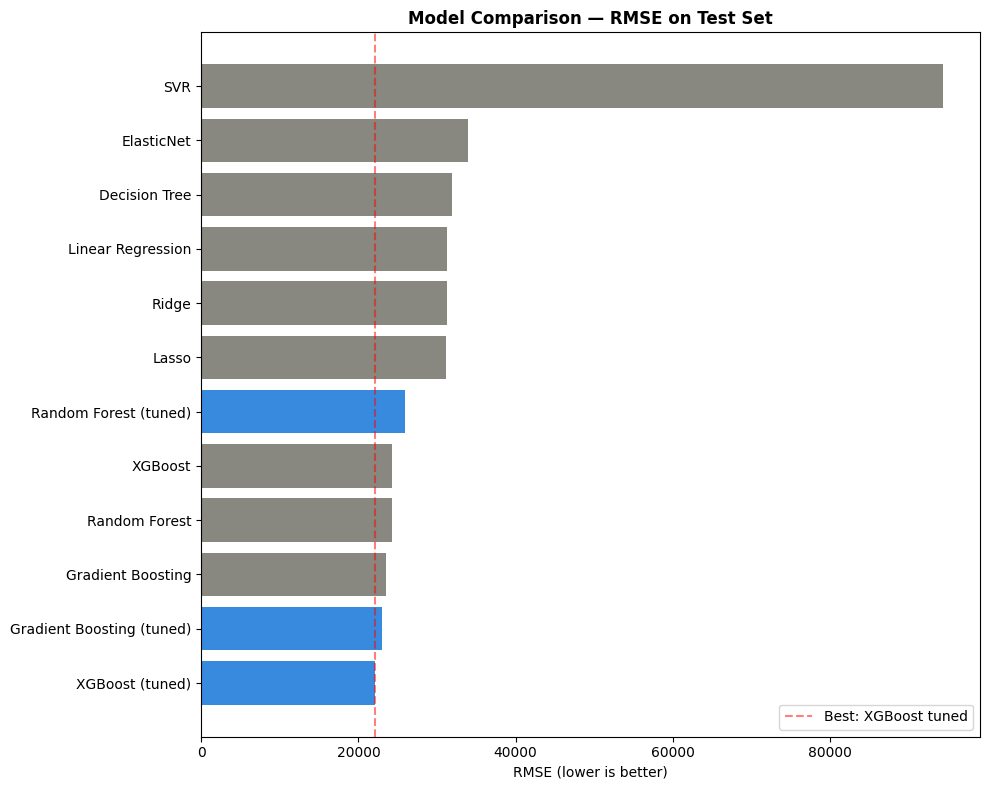

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#378ADD' if 'tuned' in m else '#888780' for m in final_results['Model']]

ax.barh(final_results['Model'], final_results['RMSE'], color=colors)
ax.set_xlabel('RMSE (lower is better)')
ax.set_title('Model Comparison — RMSE on Test Set', fontweight='bold')
ax.axvline(x=22108, color='red', linestyle='--', alpha=0.5, label='Best: XGBoost tuned')
ax.legend()
plt.tight_layout()
plt.show()

In [15]:
import pickle

with open('/content/drive/MyDrive/Housing_Project/data/models/best_xgb.pkl', 'wb') as f:
    pickle.dump(xgb_grid.best_estimator_, f)

print("Best XGBoost model saved!")

Best XGBoost model saved!
